# MAPS vs My Experiments — Results Comparison
## Cell Phenotyping on cHL CODEX Dataset

**Author**: A. M. Shahriar Rashid Mahe  
**Dataset**: cHL CODEX (~145K cells, 49 protein markers + cellSize, 16 cell types)  
**Hardware**: Local machine

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

---
## 1. MAPS Baseline Results

| Metric | MAPS Single Model | MAPS 5-Fold Ensemble | MAPS Reported |
|--------|-------------------|----------------------|---------------|
| **Weighted F1** | 86.8% | 89.7% | — |
| **Micro F1** | — | — | ~90% |
| **Method** | Pretrained `cHL_CODEX.pt` | 5 fold models averaged | 5-fold CV micro avg |

**Key finding**: MAPS reports ~90% using micro-average F1 across 5-fold CV test sets. Weighted F1 (sklearn default) is lower.

In [21]:
# ============================================================
# All Results — MAPS + My Experiments
# ============================================================

results_df = pd.DataFrame({
    'Method': [
        'MAPS Single Model',
        'MAPS 5-Fold Ensemble',
        'MAPS Reported (micro F1)',
        'My MLP — Spatial Split (Exp 1)',
        'My GNN — Spatial Split (Exp 1)',
        'My MLP — Random Split (Exp 2)',
        'My GNN — Random Split (Exp 2)',
        'My MLP — Hybrid Exp (Exp 3)',
        'My GNN — Hybrid Exp (Exp 3)',
        'My Hybrid MLP+GNN (Exp 3)',
        'My MLP — 5-Fold CV (Exp 4)',
        'My GNN — 5-Fold CV (Exp 4)'
    ],
    'F1 (%)': [86.8, 89.7, 90.0,
               86.9, 82.2, 88.2, 83.6,
               86.7, 82.1, 86.5,
               88.2, 83.2],
    'F1 Type': ['Weighted', 'Weighted', 'Micro',
                'Weighted', 'Weighted', 'Weighted', 'Weighted',
                'Weighted', 'Weighted', 'Weighted',
                'Weighted', 'Weighted'],
    'Architecture': [
        'MLP (4-layer)', 'MLP Ensemble (5x)', 'MLP Ensemble (5x)',
        'MLP (4-layer)', 'GraphSAGE (2-layer)',
        'MLP (4-layer)', 'GraphSAGE (2-layer)',
        'MLP (4-layer)', 'GraphSAGE (2-layer)', 'MLP + GraphSAGE',
        'MLP (4-layer)', 'GraphSAGE (2-layer)'],
    'Notebook': [
        '—', '—', 'MAPS paper',
        'gnn-maps-3', 'gnn-maps-3',
        'gnn-maps-4-randSplit', 'gnn-maps-4-randSplit',
        'gnn-maps-5', 'gnn-maps-5', 'gnn-maps-5',
        'gnn-maps-6-spatialCV', 'gnn-maps-6-spatialCV'],
})

def color_rows(row):
    if 'MAPS' in row['Method']:
        return ['background-color: #4f2629'] * len(row)
    elif 'GNN' in row['Method']:
        return ['background-color: #263c4f'] * len(row)
    elif 'Hybrid' in row['Method']:
        return ['background-color: #53575c'] * len(row)
    return ['background-color: #4f263d'] * len(row)

display(results_df.style.apply(color_rows, axis=1).format({'F1 (%)': '{:.1f}'}))

,Method,F1 (%),F1 Type,Architecture,Notebook
0,MAPS Single Model,86.8,Weighted,MLP (4-layer),—
1,MAPS 5-Fold Ensemble,89.7,Weighted,MLP Ensemble (5x),—
2,MAPS Reported (micro F1),90.0,Micro,MLP Ensemble (5x),MAPS paper
3,My MLP — Spatial Split (Exp 1),86.9,Weighted,MLP (4-layer),gnn-maps-3
4,My GNN — Spatial Split (Exp 1),82.2,Weighted,GraphSAGE (2-layer),gnn-maps-3
5,My MLP — Random Split (Exp 2),88.2,Weighted,MLP (4-layer),gnn-maps-4-randSplit
6,My GNN — Random Split (Exp 2),83.6,Weighted,GraphSAGE (2-layer),gnn-maps-4-randSplit
7,My MLP — Hybrid Exp (Exp 3),86.7,Weighted,MLP (4-layer),gnn-maps-5
8,My GNN — Hybrid Exp (Exp 3),82.1,Weighted,GraphSAGE (2-layer),gnn-maps-5
9,My Hybrid MLP+GNN (Exp 3),86.5,Weighted,MLP + GraphSAGE,gnn-maps-5


---
## 2. Visual Comparisons

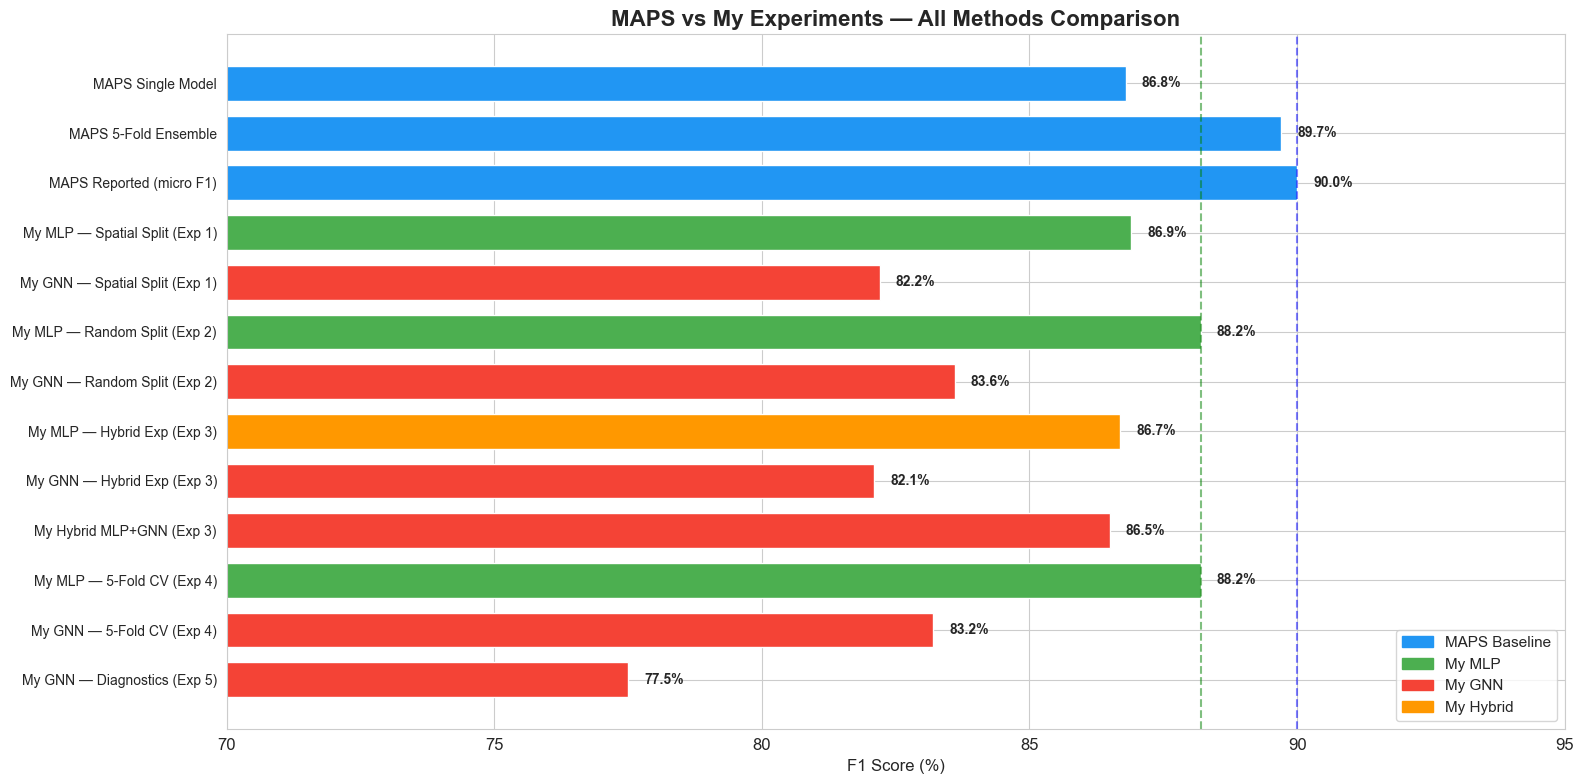

In [9]:
# ============================================================
# 2. Bar Chart: All Methods Comparison
# ============================================================

fig, ax = plt.subplots(figsize=(16, 8))

color_map = {'MAPS Baseline': '#2196F3', 'My MLP': '#4CAF50', 'My GNN': '#F44336', 'My Hybrid': '#FF9800'}

colors = []
for method in results_df['Method']:
    if 'MAPS' in method:
        colors.append(color_map['MAPS Baseline'])
    elif 'GNN' in method:
        colors.append(color_map['My GNN'])
    elif 'Hybrid' in method:
        colors.append(color_map['My Hybrid'])
    else:
        colors.append(color_map['My MLP'])

bars = ax.barh(range(len(results_df)), results_df['F1 (%)'], color=colors, edgecolor='white', height=0.7)

for bar, val in zip(bars, results_df['F1 (%)']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontweight='bold', fontsize=10)

ax.set_yticks(range(len(results_df)))
ax.set_yticklabels(results_df['Method'], fontsize=10)
ax.set_xlabel('F1 Score (%)', fontsize=12)
ax.set_title('MAPS vs My Experiments — All Methods Comparison', fontsize=16, fontweight='bold')
ax.set_xlim(70, 95)
ax.invert_yaxis()

legend_patches = [mpatches.Patch(color=c, label=l) for l, c in color_map.items()]
ax.legend(handles=legend_patches, loc='lower right', fontsize=11)

ax.axvline(x=90.0, color='blue', linestyle='--', alpha=0.5)
ax.axvline(x=88.2, color='green', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

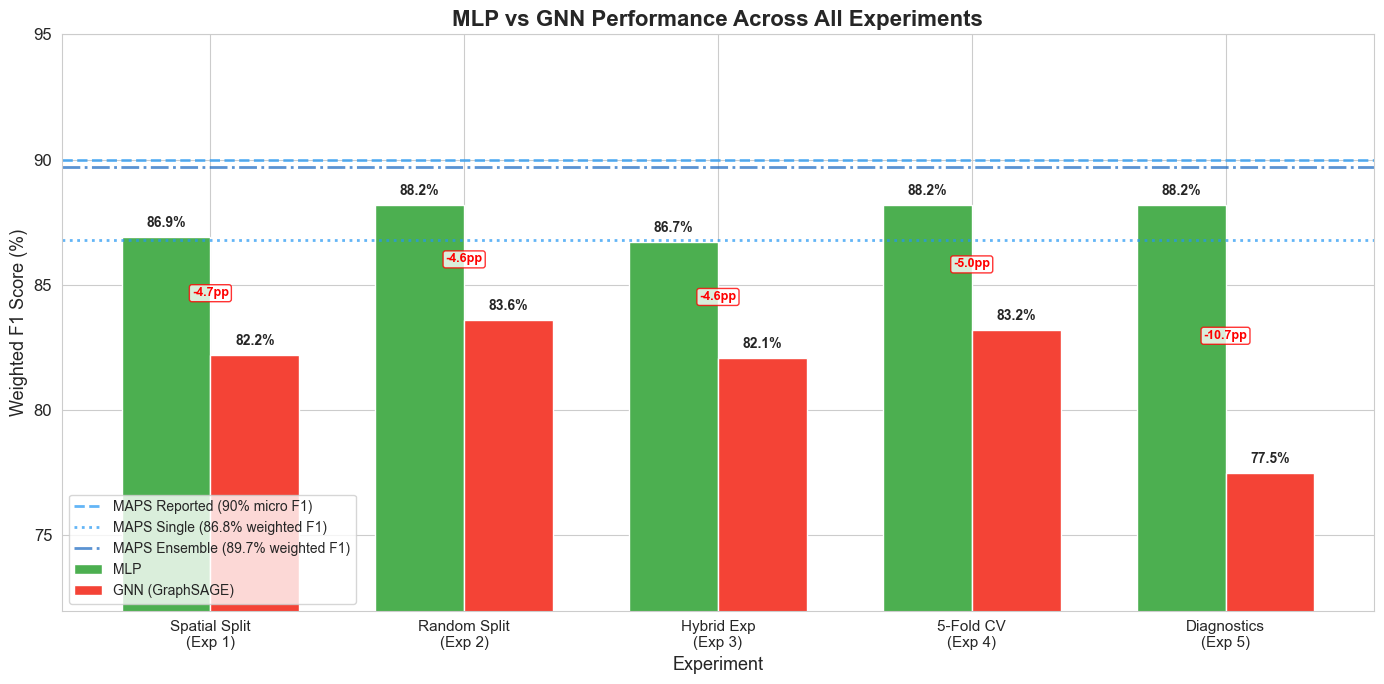

In [10]:
# ============================================================
# 3. MLP vs GNN per Experiment
# ============================================================

experiments = ['Spatial Split\n(Exp 1)', 'Random Split\n(Exp 2)', 'Hybrid Exp\n(Exp 3)', '5-Fold CV\n(Exp 4)', 'Diagnostics\n(Exp 5)']
mlp_scores = [86.9, 88.2, 86.7, 88.2, 88.2]
gnn_scores = [82.2, 83.6, 82.1, 83.2, 77.5]

x = np.arange(len(experiments))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))
bars1 = ax.bar(x - width/2, mlp_scores, width, label='MLP', color='#4CAF50', edgecolor='white')
bars2 = ax.bar(x + width/2, gnn_scores, width, label='GNN (GraphSAGE)', color='#F44336', edgecolor='white')

ax.axhline(y=90.0, color='#2196F3', linestyle='--', alpha=0.7, linewidth=2, label='MAPS Reported (90% micro F1)')
ax.axhline(y=86.8, color='#2196F3', linestyle=':', alpha=0.7, linewidth=2, label='MAPS Single (86.8% weighted F1)')
ax.axhline(y=89.7, color='#1565C0', linestyle='-.', alpha=0.7, linewidth=2, label='MAPS Ensemble (89.7% weighted F1)')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 5), textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold', fontsize=10)

for i in range(len(experiments)):
    gap = mlp_scores[i] - gnn_scores[i]
    mid_y = (mlp_scores[i] + gnn_scores[i]) / 2
    ax.annotate(f'-{gap:.1f}pp', xy=(x[i], mid_y), fontsize=9, ha='center',
                color='red', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='red', alpha=0.8))

ax.set_xlabel('Experiment', fontsize=13)
ax.set_ylabel('Weighted F1 Score (%)', fontsize=13)
ax.set_title('MLP vs GNN Performance Across All Experiments', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(experiments, fontsize=11)
ax.legend(fontsize=10, loc='lower left')
ax.set_ylim(72, 95)
plt.tight_layout()
plt.show()

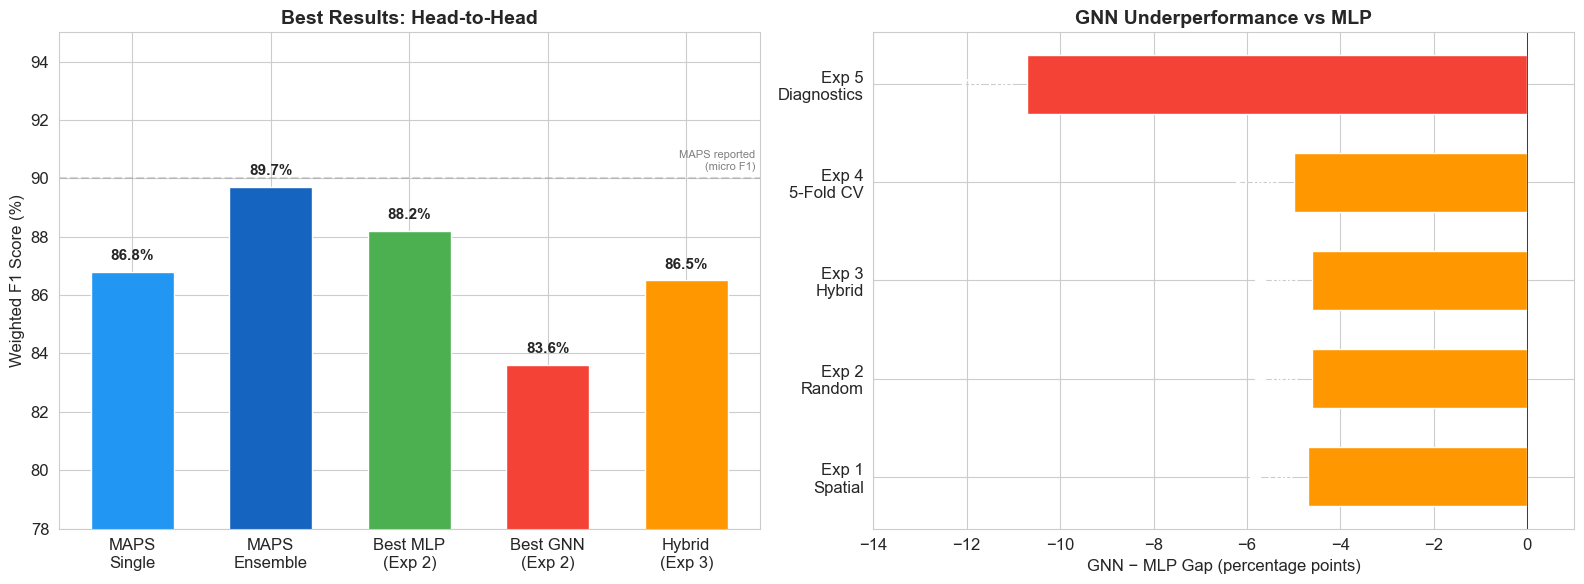

In [11]:
# ============================================================
# 4. Head-to-Head: Best of Each Approach + GNN Gap Analysis
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Best results comparison
ax = axes[0]
methods = ['MAPS\nSingle', 'MAPS\nEnsemble', 'Best MLP\n(Exp 2)', 'Best GNN\n(Exp 2)', 'Hybrid\n(Exp 3)']
scores = [86.8, 89.7, 88.2, 83.6, 86.5]
bar_colors = ['#2196F3', '#1565C0', '#4CAF50', '#F44336', '#FF9800']

bars = ax.bar(methods, scores, color=bar_colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_ylabel('Weighted F1 Score (%)', fontsize=12)
ax.set_title('Best Results: Head-to-Head', fontsize=14, fontweight='bold')
ax.set_ylim(78, 95)
ax.axhline(y=90, color='gray', linestyle='--', alpha=0.3)
ax.text(4.5, 90.3, 'MAPS reported\n(micro F1)', fontsize=8, color='gray', ha='right')

# Right: GNN underperformance gaps
ax2 = axes[1]
gap_labels = ['Exp 1\nSpatial', 'Exp 2\nRandom', 'Exp 3\nHybrid', 'Exp 4\n5-Fold CV', 'Exp 5\nDiagnostics']
gaps = [-4.7, -4.6, -4.6, -5.0, -10.7]
bar_colors2 = ['#F44336' if g < -5 else '#FF9800' for g in gaps]

bars2 = ax2.barh(gap_labels, gaps, color=bar_colors2, edgecolor='white', height=0.6)
for bar, val in zip(bars2, gaps):
    ax2.text(bar.get_width() - 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}pp', ha='right', va='center', fontweight='bold', fontsize=11, color='white')
ax2.set_xlabel('GNN − MLP Gap (percentage points)', fontsize=12)
ax2.set_title('GNN Underperformance vs MLP', fontsize=14, fontweight='bold')
ax2.axvline(x=0, color='black', linewidth=0.5)
ax2.set_xlim(-14, 1)

plt.tight_layout()
plt.show()

---
## 3. Methodology Comparison

| Aspect | MAPS (Official) | My Experiments |
|--------|-----------------|----------------|
| **Architecture** | 4-layer MLP (512 units) | MLP, GraphSAGE, Hybrid MLP+GNN |
| **Data Type** | float64 | float32 (PyTorch default) |
| **Normalization** | z-score + /255 | z-score |
| **Dropout** | 0.25 (cHL_CODEX) | 0.10 |
| **Evaluation** | 5-fold StratifiedKFold CV | Single train/valid split |
| **F1 Metric** | Micro-average across folds | Weighted F1 (sklearn) |
| **Reported F1** | ~90% (micro) | 88.2% (weighted, best MLP) |
| **Loss** | CrossEntropyLoss | CrossEntropyLoss |
| **Optimizer** | Adam | Adam |
| **Class Balancing** | WeightedRandomSampler | WeightedRandomSampler / None |

### Key Methodological Differences:
1. **F1 metric**: MAPS uses micro-average (= accuracy for single-label), we used weighted average
2. **Cross-validation**: MAPS evaluates on 5 held-out test folds; we evaluate on a single 20% validation set
3. **Dropout**: MAPS uses 0.25 for cHL_CODEX; our experiments used 0.10
4. **Data precision**: MAPS uses float64; our experiments used float32

---
## 4. GNN Failure Analysis

| Evidence | Finding | Experiment |
|----------|---------|------------|
| K-Sensitivity | K=5→25: Performance flat (77.2-77.6%) | Exp 5 |
| Random Graph Test | Random graph ≈ True KNN graph (0.04pp diff) | Exp 5 |
| No Graph Test | Empty graph **beats** true graph by 0.25pp | Exp 5 |
| Hybrid Model | Hybrid (86.5%) ≈ MLP (86.7%), GNN adds nothing | Exp 3 |
| 5-Fold CV | GNN 83.2% ± 0.74%, ALL folds below MLP | Exp 4 |
| Consistent Gap | GNN is 4.6–10.7pp worse than MLP across ALL settings | All |

### Root Cause:
- **Protein features dominate gradient flow** — 49 markers are highly discriminative on their own
- **GraphSAGE mean aggregation** dilutes individual cell protein signatures
- **Graph structure actively harmful** — spatial averaging adds noise, not signal
- **GNN degenerates to a worse MLP** — ignoring spatial edges entirely

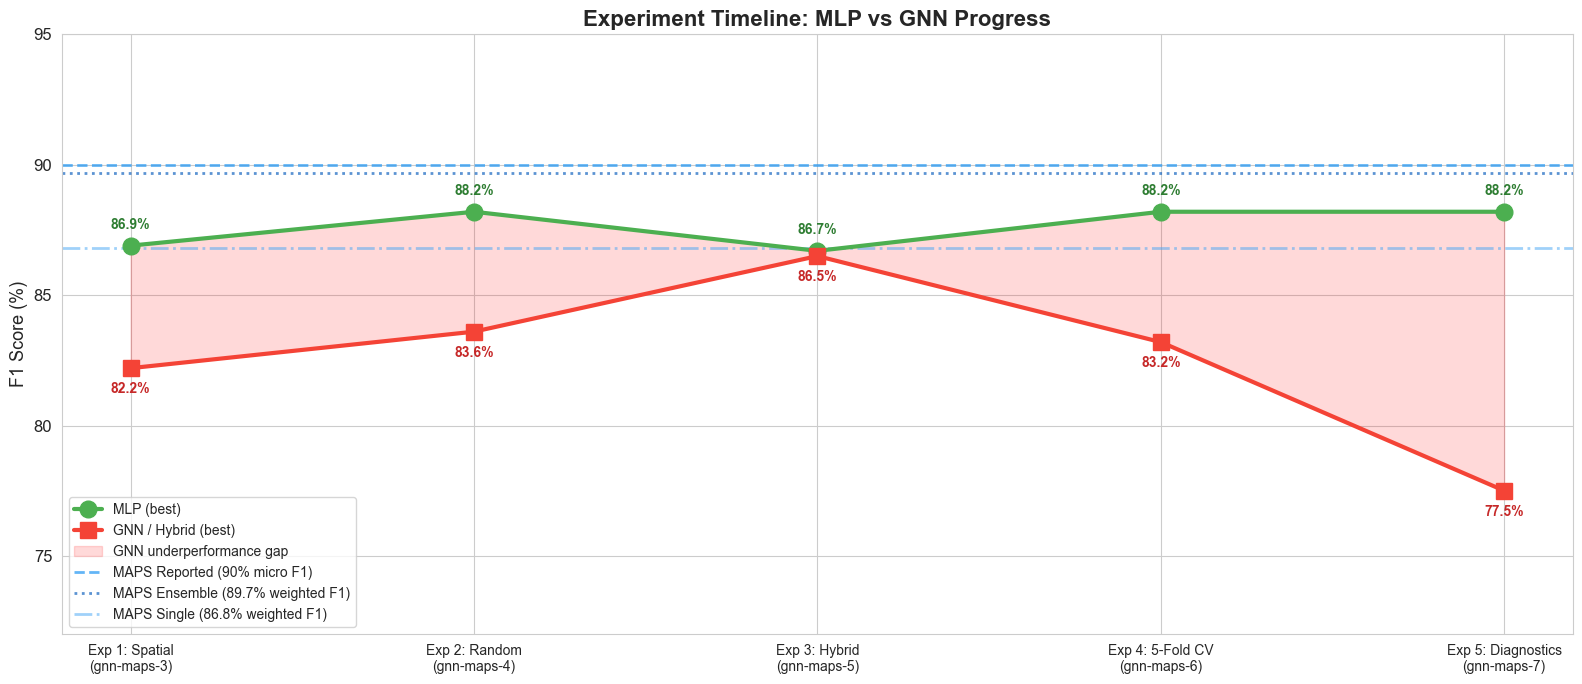

In [12]:
# ============================================================
# 5. Experiment Timeline: MLP vs GNN Progress
# ============================================================

fig, ax = plt.subplots(figsize=(16, 7))

labels = ['Exp 1: Spatial\n(gnn-maps-3)', 'Exp 2: Random\n(gnn-maps-4)', 'Exp 3: Hybrid\n(gnn-maps-5)',
          'Exp 4: 5-Fold CV\n(gnn-maps-6)', 'Exp 5: Diagnostics\n(gnn-maps-7)']
mlp_vals = [86.9, 88.2, 86.7, 88.2, 88.2]
gnn_vals = [82.2, 83.6, 86.5, 83.2, 77.5]  # Exp 3 uses Hybrid score
x = range(len(labels))

ax.plot(x, mlp_vals, 'o-', color='#4CAF50', linewidth=3, markersize=12, label='MLP (best)', zorder=5)
ax.plot(x, gnn_vals, 's-', color='#F44336', linewidth=3, markersize=12, label='GNN / Hybrid (best)', zorder=5)
ax.fill_between(x, mlp_vals, gnn_vals, alpha=0.15, color='red', label='GNN underperformance gap')

ax.axhline(y=90.0, color='#2196F3', linestyle='--', alpha=0.7, linewidth=2, label='MAPS Reported (90% micro F1)')
ax.axhline(y=89.7, color='#1565C0', linestyle=':', alpha=0.7, linewidth=2, label='MAPS Ensemble (89.7% weighted F1)')
ax.axhline(y=86.8, color='#42A5F5', linestyle='-.', alpha=0.5, linewidth=2, label='MAPS Single (86.8% weighted F1)')

for i in range(len(labels)):
    ax.annotate(f'{mlp_vals[i]}%', (i, mlp_vals[i]), textcoords="offset points", xytext=(0, 12),
                ha='center', fontweight='bold', color='#2E7D32', fontsize=10)
    ax.annotate(f'{gnn_vals[i]}%', (i, gnn_vals[i]), textcoords="offset points", xytext=(0, -18),
                ha='center', fontweight='bold', color='#C62828', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('F1 Score (%)', fontsize=13)
ax.set_title('Experiment Timeline: MLP vs GNN Progress', fontsize=16, fontweight='bold')
ax.legend(fontsize=10, loc='lower left')
ax.set_ylim(72, 95)
plt.tight_layout()
plt.show()

---
## 6. Conclusions

### Key Takeaways:

1. **MAPS's "90% F1" uses micro-average F1** across 5-fold CV test sets. Weighted F1:
   - Single model: **86.8%** | Ensemble: **89.7%**

2. **Our best MLP (88.2% weighted F1) is competitive with MAPS**:
   - Only ~1.5pp below MAPS ensemble (89.7%)
   - **Exceeds** MAPS single model (86.8%) by ~1.4pp

3. **GNN consistently failed** to leverage spatial information:
   - 4.6–10.7pp worse than MLP across ALL experiments
   - Diagnostic tests proved GNN ignores graph structure entirely

### Experiment Index

| # | Notebook | Description |
|---|----------|-------------|
| 1 | `gnn-maps-3.ipynb` | Spatial split — MLP vs GNN |
| 2 | `gnn-maps-4-randSplit.ipynb` | Random split — MLP vs GNN |
| 3 | `gnn-maps-5-protein&spatialfeatures.ipynb` | Hybrid MLP+GNN model |
| 4 | `gnn-maps-6-spatialCV.ipynb` | 5-fold spatial cross-validation |
| 5 | `gnn-maps-7-diagnostics.ipynb` | K-sensitivity, random graph, no-graph baselines |